# Day 3 — Training Dynamics & Optimization

## Note 3.3 — When Gradients Misbehave

### Learning goal and outcome

Notes 3.1 and 3.2 mostly treated the model as one object: you changed a setting, trained it, and read the loss or validation metric. That is useful, but it can hide an important class of failures.

A neural network is a chain of layers, and **each layer learns only through the gradient that reaches it**. If the gradient reaching one layer is extremely small, that layer may barely change even while the overall loss is improving. If the gradient is extremely large, one update can throw the weights into a bad numerical state. Neither problem is necessarily obvious from the loss curve alone.

This notebook therefore moves the diagnostic inside the network. You will measure the gradient received by each layer, deliberately create several ways for gradient flow to fail, and then connect each failure to a specific intervention.

By the end, the goal is not to memorise a collection of fixes. It is to look at a broken training run and ask: **which part of the computation is failing, what evidence would reveal it, and which mechanism explains that evidence?**

### Objectives

- Turn the single gradient-norm probe from Day 2 into a reusable **per-layer diagnostic**
- Explain why **weight initialisation** affects whether a network can learn effectively at all
- Measure **vanishing gradients** and explain how the chain rule and saturating activations cause them
- Measure **exploding gradients** and understand what gradient clipping actually changes
- Detect **dead ReLU units** and connect them to the learning-rate collapse from Note 3.1
- Explain what **BatchNorm** and **LayerNorm** normalise, how they affect gradient flow, and why their use differs
- Explain why a **residual connection** creates a direct route for gradients
- Apply a compact **layer-health checklist** to an unfamiliar model

### Dataset

**German Credit**, exactly as prepared in Note 3.2 — 500 training rows, 250 validation rows, and 61 features after encoding.

The dataset is deliberately in the background. The problems studied here are mainly properties of the computation graph and architecture, not special properties of German Credit. A deep sigmoid network can suffer from vanishing gradients on many datasets.

One important scope note: a 12-layer MLP is not a sensible model choice for only 500 training examples. Here, depth is being used as an **instrument**: it makes the gradient behaviour large enough to measure and inspect. The same mechanisms become practically important in much deeper models, including Transformers, where normalisation and residual connections are structural parts of the architecture.

### Table of contents

1. [A per-layer gradient probe](#s1)
2. [Initialisation is not a detail](#s2)
3. [Vanishing gradients](#s3)
4. [Exploding gradients, and clipping](#s4)
5. [Dead ReLU units](#s5)
6. [Normalisation as a stabiliser](#s6)
7. [Residual connections in one line](#s7)
8. [A layer-health checklist](#s8)


In [1]:
# torch 2.14.0 | scikit-learn 1.8.0 | numpy 2.4.4 | pandas 3.0.2 | matplotlib 3.10.8
import numpy as np, torch, torch.nn as nn, matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score

DEVICE = torch.device("cpu"); SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

gc = fetch_openml("credit-g", version=1, as_frame=True)
X_raw = gc.data.copy(); y_raw = (gc.target == "bad").astype(np.float32).values
gnum = X_raw.select_dtypes(include="number").columns.tolist()
gcat = [c for c in X_raw.columns if c not in gnum]
X_tr_r, X_tmp, y_tr, y_tmp = train_test_split(X_raw, y_raw, train_size=500, random_state=SEED, stratify=y_raw)
X_va_r, X_te_r, y_va, y_te = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=SEED, stratify=y_tmp)
pre = ColumnTransformer([("n", StandardScaler(), gnum),
                         ("c", OneHotEncoder(handle_unknown="ignore", sparse_output=False), gcat)])
A_tr = pre.fit_transform(X_tr_r).astype(np.float32)
A_va = pre.transform(X_va_r).astype(np.float32)
D = A_tr.shape[1]
Xt = torch.tensor(A_tr); Yt = torch.tensor(y_tr).unsqueeze(1)
Xv = torch.tensor(A_va); Yv = torch.tensor(y_va).unsqueeze(1)
loss_fn = nn.BCEWithLogitsLoss()
print(f"torch {torch.__version__} | train {A_tr.shape} val {A_va.shape} | features {D}")


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
torch 2.14.0 | train (500, 61) val (250, 61) | features 61


<a id="s1"></a>
## 1. A per-layer gradient probe

In Day 2, Note 2.3 §9 you computed one gradient norm after `loss.backward()`. That number is useful as a quick check that *some* gradient exists, but it combines information from all parameters.

That combination can hide the problem we care about. Imagine the first layer has gradient norm `1e-10` while the last layer has gradient norm `1.0`. The total can still look perfectly ordinary because the large gradient from the last layer dominates the summary.

So we need a more informative measurement: **the gradient norm for each layer separately**.

The important idea is simple:

- `loss.backward()` computes how much the loss would change if each parameter changed.
- `p.grad` stores that gradient for parameter `p`.
- The norm, such as `p.grad.norm()`, gives one number describing the overall size of that parameter's gradient.
- Looking at those numbers from the first layer to the last lets us see whether the learning signal is reaching every part of the network.

We are not measuring whether a layer is "good" in isolation. We are measuring whether the backward signal reaching different depths is on a comparable scale.

In [2]:
def layer_grad_norms(model, xb, yb, loss_function=None):
    """Run one forward/backward pass and return the gradient norm of each weight matrix.

    This is the Day 2 probe, computed per layer instead of summed.
    Returns a list of (name, grad_norm) for 2-D weight tensors, in forward order.
    """
    loss_function = loss_function or loss_fn
    model.train()
    model.zero_grad()
    loss = loss_function(model(xb), yb)
    loss.backward()
    out = []
    for name, p in model.named_parameters():
        if p.grad is not None and p.dim() > 1:          # weight matrices only, skip biases
            out.append((name, p.grad.norm().item()))
    model.zero_grad()
    return out

def summarise(tag, norms):
    first, last = norms[0][1], norms[-1][1]
    ratio = last / max(first, 1e-30)
    print(f"{tag:<22} first {first:.3e}   mid {norms[len(norms)//2][1]:.3e}   "
          f"last {last:.3e}   last/first {ratio:.3e}")
    return ratio

def plot_profiles(profiles, title):
    plt.figure(figsize=(9, 4.2))
    for tag, norms in profiles.items():
        plt.plot(range(1, len(norms)+1), [n for _, n in norms], "o-", ms=4, lw=1.7, label=tag)
    plt.yscale("log"); plt.xlabel("layer (1 = closest to input)")
    plt.ylabel("gradient norm (log scale)"); plt.title(title)
    plt.legend(fontsize=9); plt.grid(alpha=0.3, which="both")
    plt.tight_layout(); plt.show()

# sanity check on a shallow, healthy network
torch.manual_seed(SEED)
shallow = nn.Sequential(nn.Linear(D,64), nn.ReLU(), nn.Linear(64,32), nn.ReLU(), nn.Linear(32,1))
for n, g in layer_grad_norms(shallow, Xt[:256], Yt[:256]):
    print(f"  {n:<12} grad norm {g:.4e}")


  0.weight     grad norm 1.1257e-01
  2.weight     grad norm 1.5730e-01
  4.weight     grad norm 1.4339e-01


On a shallow, healthy network, the gradient norms of the layers are usually in roughly the same order of magnitude. That does **not** mean they must be identical. It means there is no enormous systematic gap where one part of the network receives a useful learning signal and another receives almost none.

Think of this function as an instrument rather than as part of the model. We will use it throughout the notebook to answer a specific diagnostic question:

> **Where in the network is the learning signal becoming too small or too large?**

Note 3.4 will eventually connect this probe to the config-driven runner from Day 2 so that the same measurement can be recorded automatically during experiments.

<a id="s2"></a>
## 2. Initialisation is not a detail

Before training begins, every trainable weight needs an initial numerical value. **Initialisation** is the rule used to choose those starting values.

It is tempting to regard this as a minor implementation detail because the optimizer will change the weights anyway. But the starting values determine the scale of the first activations and gradients, and they can also determine whether different hidden units begin with different behaviour.

We will compare three schemes while keeping the architecture and training procedure fixed:

1. sensible framework-style initialisation;
2. all-zero weights;
3. deliberately enormous weights.

The point is not to memorise one magic initialisation formula. The point is to understand what a broken initialisation looks like and why it breaks.

In [3]:
def build_with_init(kind, seed=SEED):
    torch.manual_seed(seed)
    m = nn.Sequential(nn.Linear(D,64), nn.ReLU(), nn.Linear(64,32), nn.ReLU(), nn.Linear(32,1))
    if kind == "default":
        return m                                   # PyTorch's own initialisation
    for mod in m:
        if isinstance(mod, nn.Linear):
            if kind == "zeros":
                nn.init.zeros_(mod.weight); nn.init.zeros_(mod.bias)
            elif kind == "big":
                nn.init.normal_(mod.weight, 0.0, 3.0); nn.init.zeros_(mod.bias)
            elif kind == "kaiming":
                nn.init.kaiming_normal_(mod.weight, nonlinearity="relu"); nn.init.zeros_(mod.bias)
    return m

def short_train(model, epochs=8, lr=1e-3, bs=32, seed=SEED):
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    g = torch.Generator().manual_seed(seed)
    dl = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(Xt, Yt),
                                     batch_size=bs, shuffle=True, generator=g)
    losses = []
    for ep in range(epochs):
        model.train(); tot = n = 0
        for xb, yb in dl:
            opt.zero_grad(); l = loss_fn(model(xb), yb); l.backward(); opt.step()
            tot += l.item()*len(xb); n += len(xb)
        losses.append(tot/n)
    model.eval()
    with torch.no_grad():
        auc = roc_auc_score(y_va, torch.sigmoid(model(Xv)).numpy().ravel())
    return losses, auc

for kind in ["zeros", "big", "kaiming", "default"]:
    m = build_with_init(kind)
    losses, auc = short_train(m)
    print(f"{kind:<9} epoch losses {' '.join(f'{x:9.4f}' for x in losses[:4])} ...   val AUC {auc:.4f}")


zeros     epoch losses    0.6918    0.6889    0.6860    0.6832 ...   val AUC 0.5000
big       epoch losses  641.5191  548.8349  483.1462  448.8655 ...   val AUC 0.5329


kaiming   epoch losses    0.6495    0.5829    0.5435    0.5150 ...   val AUC 0.8153
default   epoch losses    0.6975    0.6317    0.5880    0.5700 ...   val AUC 0.8133


In [4]:
# Why zeros fails: check whether the hidden units differ from each other at all.
m0 = build_with_init("zeros")
_ = short_train(m0, epochs=3)
W1 = m0[0].weight.detach()
print("after 3 epochs of training from an all-zeros init:")
print(f"  layer-1 weight matrix shape {tuple(W1.shape)}")
print(f"  number of DISTINCT rows (hidden units): {len(torch.unique(W1, dim=0))}")
print(f"  std across the 64 hidden units: {W1.std(dim=0).mean().item():.3e}")
print()
print("Every hidden unit received the same gradient and made the same update,")
print("so all 64 units are identical. The layer has the expressive power of ONE unit.")
print()
mb = build_with_init("big")
print("Why a too-large init fails:")
with torch.no_grad():
    h = mb[0](Xt[:256])
print(f"  pre-activation std at layer 1: {h.std().item():.2f}   (healthy is around 1)")
print(f"  fraction of activations killed by ReLU: {(mb[1](h) == 0).float().mean().item():.1%}")


after 3 epochs of training from an all-zeros init:
  layer-1 weight matrix shape (64, 61)
  number of DISTINCT rows (hidden units): 1
  std across the 64 hidden units: 0.000e+00

Every hidden unit received the same gradient and made the same update,
so all 64 units are identical. The layer has the expressive power of ONE unit.

Why a too-large init fails:
  pre-activation std at layer 1: 12.76   (healthy is around 1)
  fraction of activations killed by ReLU: 50.7%


Two different failures appear here, and they have different mechanisms.

### All zeros: the symmetry problem

If every weight in a layer starts at exactly the same value, the hidden units start in exactly the same state. They therefore produce the same activations, receive the same gradients, and make the same updates. Nothing distinguishes one unit from another, so they remain identical.

This is called **symmetry**. A 64-unit layer may contain 64 parameter sets, but if all those units behave identically, the network is not getting 64 independent pieces of representation.

Random initialisation is therefore not mainly about adding randomness for its own sake. Its important job is to **break symmetry**, giving different units slightly different starting points so they can specialise.

### Very large weights: the scale problem

With a standard deviation of 3.0, the initial weights are deliberately far too large. That produces very large pre-activations and a huge starting loss. For ReLU networks, many units can also be pushed into the negative region, where ReLU outputs zero and has zero derivative.

The network is no longer failing because its units are identical. It is failing because the numerical scale of the computation is badly behaved.

### What sensible initialisation is trying to preserve

Kaiming-style initialisation chooses the scale of weights using the number of inputs to a layer. The aim is to keep the variance of activations from changing wildly as the signal moves forward through the network.

PyTorch's standard `Linear` initialisation is already designed to give sensible starting scales, so you usually do **not** need to hand-design initialisation for ordinary layers.

What you do need to recognise are the signatures of a broken start:

- a loss that begins at an absurdly large value;
- a metric that remains at chance;
- gradients that are essentially zero;
- or activations that immediately become numerically extreme.

**Check your understanding.** If all weights are zero but the biases are non-zero, why does the symmetry problem remain? And if every weight is instead set to the same non-zero value such as `0.1`, what has changed — and what has not?

<a id="s3"></a>
## 3. Vanishing gradients

Now we reach a failure that becomes much more important as a network gets deeper.

**Backpropagation uses the chain rule.** To find how the loss changes with respect to an early layer, the gradient is passed backward through every operation between that layer and the loss. In simplified form, those local derivatives are multiplied together.

That creates a simple numerical effect:

- if many factors are smaller than `1`, their product becomes very small;
- if many factors are larger than `1`, their product can become very large.

For example, multiplying by `0.3` twelve times gives roughly `5e-7`. The exact network is more complicated than this toy calculation, but the principle is the same.

The sigmoid activation makes the first case especially visible. Its derivative is never larger than `0.25`, and it becomes much smaller when the sigmoid is saturated near 0 or 1.

Let's measure what happens as the gradient travels through a deep network.

In [5]:
def deep_net(activation="sigmoid", n_layers=12, width=64, norm=None, seed=0):
    """A deep MLP. `norm` may be None, 'ln' (LayerNorm) or 'bn' (BatchNorm1d)."""
    torch.manual_seed(seed)
    Act = nn.Sigmoid if activation == "sigmoid" else nn.ReLU
    layers = [nn.Linear(D, width), Act()]
    for _ in range(n_layers - 2):
        layers.append(nn.Linear(width, width))
        if norm == "ln": layers.append(nn.LayerNorm(width))
        if norm == "bn": layers.append(nn.BatchNorm1d(width))
        layers.append(Act())
    layers.append(nn.Linear(width, 1))
    return nn.Sequential(*layers)

profiles = {}
xb, yb = Xt[:256], Yt[:256]
for tag, act in [("12-layer sigmoid", "sigmoid"), ("12-layer ReLU", "relu")]:
    norms = layer_grad_norms(deep_net(act), xb, yb)
    profiles[tag] = norms
    summarise(tag, norms)

print()
print("For reference, the 3-layer healthy network:")
summarise("3-layer ReLU", layer_grad_norms(build_with_init("default"), xb, yb))


12-layer sigmoid       first 1.859e-10   mid 5.458e-05   last 1.111e+00   last/first 5.977e+09
12-layer ReLU          first 2.421e-05   mid 1.066e-03   last 1.100e-01   last/first 4.545e+03

For reference, the 3-layer healthy network:
3-layer ReLU           first 1.126e-01   mid 1.573e-01   last 1.434e-01   last/first 1.274e+00


1.2737144876680562

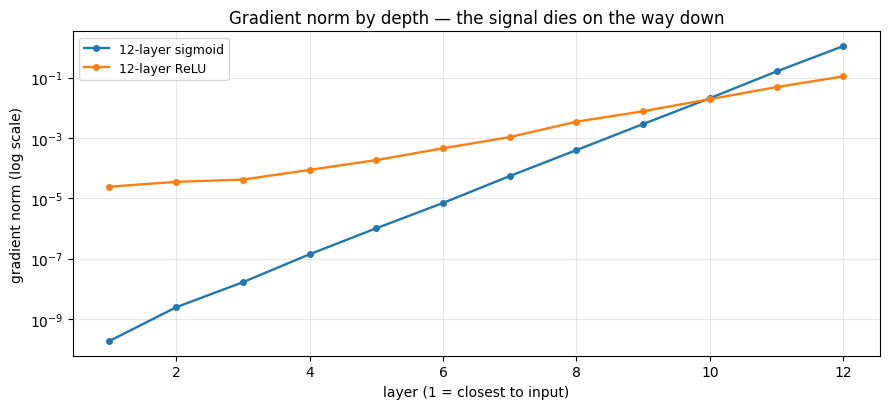

In [6]:
plot_profiles(profiles, "Gradient norm by depth — the signal dies on the way down")


The numbers are stark. In the 12-layer sigmoid network, the gradient reaching the first layer is roughly **nine orders of magnitude smaller** than the gradient reaching the last layer.

What does that mean in practice?

The layers near the output are receiving a usable learning signal. The layers near the input are receiving such a tiny signal that their weights may barely change at all. The network can therefore reduce the loss while a large portion of its depth contributes very little learning.

This is an important diagnostic lesson: **a falling loss does not prove that every layer is training properly.**

ReLU improves the situation because its derivative is `1` whenever its input is positive. In that active region, ReLU itself does not shrink the gradient. That is one major reason ReLU became a standard hidden activation instead of sigmoid.

But ReLU alone does not guarantee healthy gradient flow. In a deep network, the product of the linear-layer derivatives can still create a large difference between early and late layers. Sections 6 and 7 introduce two structural tools that address this more directly: normalisation and residual connections.

The same chain-rule issue also helps explain why very deep recurrent networks historically had difficulty learning long-range dependencies. An RNN unrolled over many time steps creates a long sequence of transformations through which the gradient must travel. LSTMs introduced gating mechanisms that provided additional ways for information and gradients to persist. Attention takes a different route by allowing positions to interact without requiring every dependency to pass through one long sequential chain.

<div align="center">

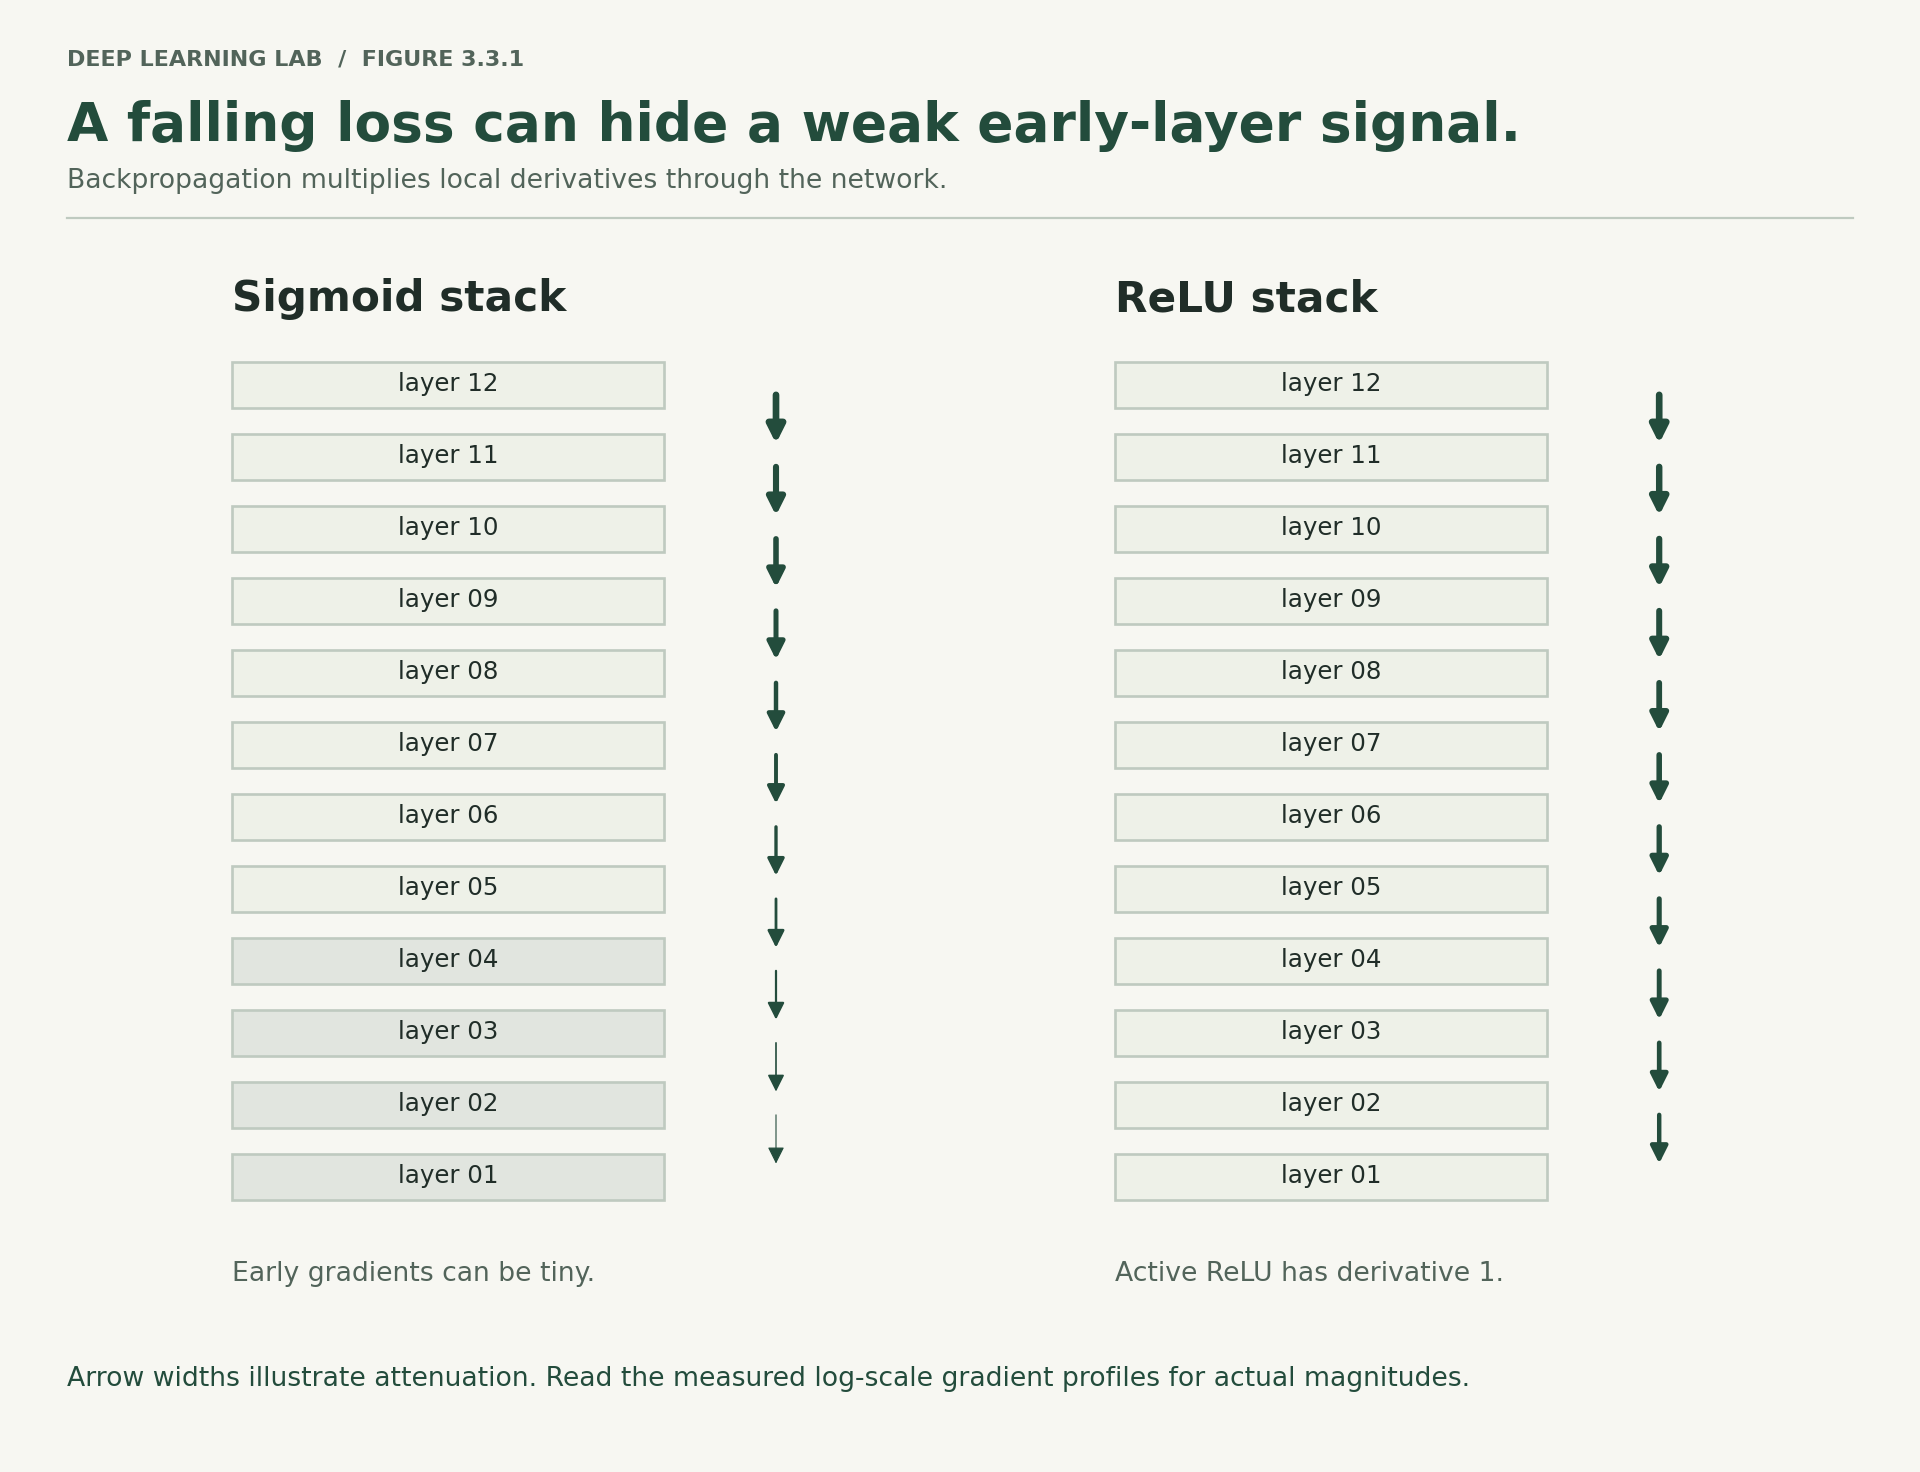

<p><b>Figure 3.3.1.</b> Schematic backward signal through twelve layers. Sigmoid can strongly attenuate gradients; active ReLU avoids attenuation by the activation itself but does not guarantee healthy flow.</p>

</div>

**Check your understanding.** The profile above was measured on an *untrained* network, immediately after initialisation. Would you expect the sigmoid network's gradient profile to become healthier or worse after many training steps? Explain your reasoning in terms of **saturation**: what happens to the sigmoid derivative when its inputs become very positive or very negative?

<a id="s4"></a>
## 4. Exploding gradients, and clipping

The same chain-rule mechanism can fail in the opposite direction.

If the factors being multiplied through the backward pass are repeatedly greater than `1`, the product grows rapidly with depth. The result is an **exploding gradient**: an unusually large gradient reaches some parameters, producing an unusually large parameter update.

A common symptom is a training run that appears normal and then suddenly:

- the loss jumps to an enormous value;
- the loss becomes `NaN` or `Inf`;
- activations or weights become numerically extreme;
- or the next few updates are completely unusable.

The important point is that one oversized update can be enough to destabilise the rest of training.

Gradient clipping is a direct way to limit that update. The next experiment shows what it does and, just as importantly, what it does **not** do.

In [7]:
explode = deep_net("relu", n_layers=12)
for mod in explode:
    if isinstance(mod, nn.Linear):
        nn.init.normal_(mod.weight, 0.0, 1.5)          # deliberately too large

explode.train(); explode.zero_grad()
loss_fn(explode(xb), yb).backward()
total = torch.sqrt(sum(p.grad.pow(2).sum() for p in explode.parameters())).item()
print(f"total gradient norm with a 1.5-sigma init: {total:.3e}")
print()

lr = 1e-3
with torch.no_grad():
    biggest = max(p.grad.abs().max().item() for p in explode.parameters())
print(f"largest single gradient element: {biggest:.3e}")
print(f"at lr={lr}, that one weight would move by {lr*biggest:.3e} in a single step")
print("   (a typical healthy weight has magnitude around 0.1)")


total gradient norm with a 1.5-sigma init: 4.306e+10

largest single gradient element: 8.832e+09
at lr=0.001, that one weight would move by 8.832e+06 in a single step
   (a typical healthy weight has magnitude around 0.1)


In [8]:
# Gradient clipping: rescale the whole gradient if its norm exceeds a threshold.
explode2 = deep_net("relu", n_layers=12)
for mod in explode2:
    if isinstance(mod, nn.Linear):
        nn.init.normal_(mod.weight, 0.0, 1.5)
explode2.train(); explode2.zero_grad()
loss_fn(explode2(xb), yb).backward()

before = nn.utils.clip_grad_norm_(explode2.parameters(), max_norm=1.0)   # returns the PRE-clip norm
after = torch.sqrt(sum(p.grad.pow(2).sum() for p in explode2.parameters())).item()
print(f"norm before clipping: {before.item():.3e}")
print(f"norm after clipping : {after:.4f}")
print()
print("Where it goes in the training loop:")
print("    loss.backward()")
print("    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)   # <- between")
print("    optimizer.step()")
print()
print("Clipping preserves the DIRECTION of the gradient and caps only its LENGTH.")


norm before clipping: 4.306e+10
norm after clipping : 1.0000

Where it goes in the training loop:
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)   # <- between
    optimizer.step()

Clipping preserves the DIRECTION of the gradient and caps only its LENGTH.


Gradient clipping rescales the gradient when its norm is larger than a chosen threshold.

Suppose the gradient vector has norm `10` and the threshold is `1`. Clipping scales the whole vector down so that its norm becomes `1`. The **direction stays the same**; only the magnitude changes.

That gives clipping a very specific role: it prevents a single update from being catastrophically large. It does not discover why the gradient became large in the first place.

The placement is important enough to memorise:

**`backward()` → clip gradients → `step()`**

Clipping before `backward()` would not clip the gradients produced by the current loss. Clipping after `step()` would be too late because the oversized parameter update has already happened.

A threshold such as `1.0` is a common starting point, but there is no universal threshold that is correct for every model. The right lesson is not "always use 1.0." It is:

> **Use clipping as protection against unusually large updates, then investigate the cause if clipping is happening constantly.**

If gradients repeatedly hit the clipping threshold, possible causes include poor initialisation, an excessive learning rate, or badly scaled inputs. Continually lowering the threshold can hide the symptom without fixing the underlying problem.

<a id="s5"></a>
## 5. Dead ReLU units

ReLU is defined as `max(0, x)`.

That simple definition gives it a useful property: for positive inputs, its derivative is `1`, so active units do not shrink the gradient. But it also creates a hard failure mode.

For negative inputs, ReLU outputs exactly `0`, and its derivative is `0`. If a hidden unit ends up producing negative pre-activations for **every training example**, that unit receives no useful gradient from those examples. It can become permanently inactive — a **dead ReLU**.

This is different from ordinary overfitting or poor performance. The problem is local: a particular unit has effectively stopped participating in learning.

Note 3.1 gave us a suspected cause: the very large learning rate that caused the model to collapse to a constant prediction. Here we will measure whether dead units are the mechanism behind that collapse.

In [9]:
def dead_fraction(model, X, layer_idx=1):
    """Fraction of units in the given ReLU layer that output 0 for EVERY row."""
    model.eval()
    with torch.no_grad():
        acts = model[layer_idx](model[0](X))
    return (acts.max(dim=0).values == 0).float().mean().item()

print(f"{'learning rate':>14}{'dead layer-1 units':>22}{'val AUC':>10}")
print("-" * 46)
for lr in [1e-3, 1e-2, 1e-1, 0.5, 2.0]:
    torch.manual_seed(SEED)
    m = nn.Sequential(nn.Linear(D,64), nn.ReLU(), nn.Linear(64,32), nn.ReLU(), nn.Linear(32,1))
    opt = torch.optim.AdamW(m.parameters(), lr=lr)
    g = torch.Generator().manual_seed(SEED)
    dl = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(Xt, Yt),
                                     batch_size=32, shuffle=True, generator=g)
    for _ in range(5):
        m.train()
        for xb_, yb_ in dl:
            opt.zero_grad(); loss_fn(m(xb_), yb_).backward(); opt.step()
    m.eval()
    with torch.no_grad():
        auc = roc_auc_score(y_va, torch.sigmoid(m(Xv)).numpy().ravel())
    print(f"{lr:>14}{dead_fraction(m, Xt):>21.1%}{auc:>10.4f}")


 learning rate    dead layer-1 units   val AUC
----------------------------------------------
         0.001                 0.0%    0.7808
          0.01                12.5%    0.7955


           0.1                43.8%    0.7367
           0.5                60.9%    0.5000
           2.0                60.9%    0.5000


There is the causal chain that Note 3.1 could only suggest.

A learning rate that is too large can move the first-layer weights so far in one update that many ReLU units are pushed permanently into their zero-output region. Once a unit is dead, its gradient is zero, so later updates cannot bring it back. If enough units die, the layer loses most of its useful representation capacity and the whole model can collapse toward a constant prediction — hence AUC near `0.5`.

But do not turn this into the rule **"any dead ReLU is bad."** A modest fraction of inactive units can be completely harmless. Neural networks are often over-parameterised, so the surviving units can carry the useful computation.

What matters is the **fraction** of a layer that has become inactive and whether that loss of capacity is associated with degraded model behaviour.

This failure is permanent for the current training run. Lowering the learning rate after the units have died does not give them a gradient to recover with. In practice, you normally restart training after fixing the cause.

Useful responses include:

- **Lower the learning rate** when large updates are the cause.
- **Use LeakyReLU or GELU** when you want a non-zero gradient on the negative side.
- **Check input scaling.** Features with very different or very large scales can create extreme pre-activations and gradients. The `StandardScaler` in this pipeline is therefore part of the numerical-stability story, not merely cosmetic preprocessing.

The measurement is simple enough to keep in your diagnostic toolkit: ask what fraction of units in a layer never activate on the data being inspected.

**Check your understanding.** The function above tests whether a unit is inactive for every training row. Could a unit be active somewhere in the training set but inactive for every validation row? If so, what might that tell you about the relationship between the training and validation feature distributions?

<a id="s6"></a>
## 6. Normalisation as a stabiliser

The previous sections showed two opposite gradient problems: gradients can become extremely small or extremely large as they pass through depth.

A useful way to understand both is to focus on **scale**. If the activations entering each layer become progressively too large or too small, the local derivatives in the chain rule can also become badly scaled. That makes the product through many layers unstable.

**Normalisation layers** try to control that scale by rescaling activations during the forward pass.

The two normalisation schemes we need to distinguish are based on different sets of values:

- **BatchNorm** normalises each feature using statistics computed across the examples in the current batch. For a particular feature, it asks: "How are the values for this feature distributed across these rows?"
- **LayerNorm** normalises each individual example across its features. For one row, it asks: "How are this example's feature activations distributed?"

So the difference is not simply two names for the same operation. They use different axes and therefore have different behaviour with respect to batch size and evaluation mode.

Let's measure how these choices affect gradient flow.

In [10]:
norm_profiles = {}
for tag, kw in [("no norm",    dict(norm=None)),
                ("LayerNorm",  dict(norm="ln")),
                ("BatchNorm",  dict(norm="bn"))]:
    norms = layer_grad_norms(deep_net("relu", n_layers=12, **kw), xb, yb)
    norm_profiles[tag] = norms
    summarise(f"12-layer ReLU, {tag}", norms)


12-layer ReLU, no norm first 2.421e-05   mid 1.066e-03   last 1.100e-01   last/first 4.545e+03
12-layer ReLU, LayerNorm first 1.571e-01   mid 8.388e-01   last 1.149e+00   last/first 7.313e+00
12-layer ReLU, BatchNorm first 1.154e+00   mid 3.651e-01   last 8.440e-01   last/first 7.316e-01


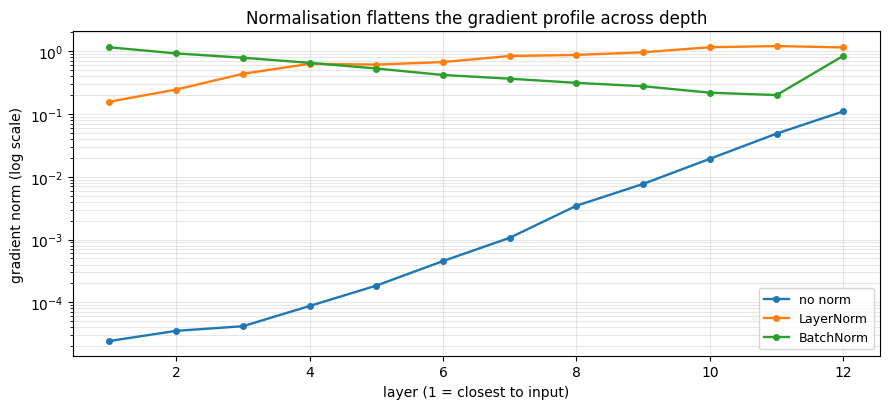

In [11]:
plot_profiles(norm_profiles, "Normalisation flattens the gradient profile across depth")


This experiment shows the structural effect clearly. In the plain 12-layer ReLU network, the gradient reaching the last layer can be thousands of times larger than the gradient reaching the first. Adding LayerNorm reduces that gap to single digits, while BatchNorm brings it close to one in this particular experiment.

The important lesson is not that BatchNorm will *always* beat LayerNorm numerically. The lesson is that **normalisation can keep the scale of intermediate activations and gradients under control**, making deep stacks easier to train.

### BatchNorm

BatchNorm computes statistics across examples in a batch. That creates a dependency between rows: during training, the representation of one row is partly determined by the other rows that happen to be in the same batch.

That can work very well, particularly in convolutional vision models, but it becomes less convenient with very small or variable batches.

It also explains why `model.train()` and `model.eval()` matter. During training, BatchNorm uses batch statistics and updates running statistics. During evaluation, it uses the stored running statistics instead of recomputing them from the evaluation batch.

### LayerNorm

LayerNorm normalises each example independently across its features. There is therefore no dependence on the other rows in the batch.

That property is particularly useful for sequence models and Transformers, where batch composition should not determine how an individual sequence is normalised. LayerNorm is consequently a standard component of Transformer architectures.

You do not need to derive the backward pass here. What you should be able to explain is **what is being normalised, over which dimensions, and why that choice matters**.

**Check your understanding.** Why is it acceptable for BatchNorm to use information from other rows during training, but not desirable to recompute those batch statistics independently at inference time? What does PyTorch do differently in `eval()` mode?

<a id="s7"></a>
## 7. Residual connections in one line

Normalisation changes the **scale** of the signal. A residual connection changes the **route** the signal takes.

A plain block computes:

`y = f(x)`

A residual block computes:

`y = x + f(x)`

The original input `x` is therefore passed directly to the output as well as through the learned transformation `f`.

Why does this help gradients?

Differentiate the expression with respect to `x`:

`dy/dx = 1 + f'(x)`

The important part is the constant `1`. Even if the derivative through `f` becomes very small, the gradient still has a direct path through the `x` term.

This is the core idea. You do not need a complicated derivation to remember it:

> **A residual connection gives the gradient a route that bypasses the transformation.**

That route becomes extremely valuable when many blocks are stacked.

In [12]:
class ResidualBlock(nn.Module):
    """The whole idea: return x + f(x) instead of f(x)."""
    def __init__(self, width=64):
        super().__init__()
        self.f = nn.Sequential(nn.Linear(width, width), nn.ReLU())
    def forward(self, x):
        return x + self.f(x)                      # <- the residual connection

def deep_residual(n_layers=12, width=64, residual=False, seed=0):
    torch.manual_seed(seed)
    layers = [nn.Linear(D, width), nn.ReLU()]
    for _ in range(n_layers - 2):
        layers.append(ResidualBlock(width) if residual
                      else nn.Sequential(nn.Linear(width, width), nn.ReLU()))
    layers.append(nn.Linear(width, 1))
    return nn.Sequential(*layers)

res_profiles = {}
for tag, flag in [("plain (12 layers)", False), ("residual (12 layers)", True)]:
    norms = layer_grad_norms(deep_residual(residual=flag), xb, yb)
    res_profiles[tag] = norms
    summarise(tag, norms)


plain (12 layers)      first 2.421e-05   mid 1.066e-03   last 1.100e-01   last/first 4.545e+03
residual (12 layers)   first 7.441e-01   mid 1.061e+00   last 7.006e+00   last/first 9.416e+00


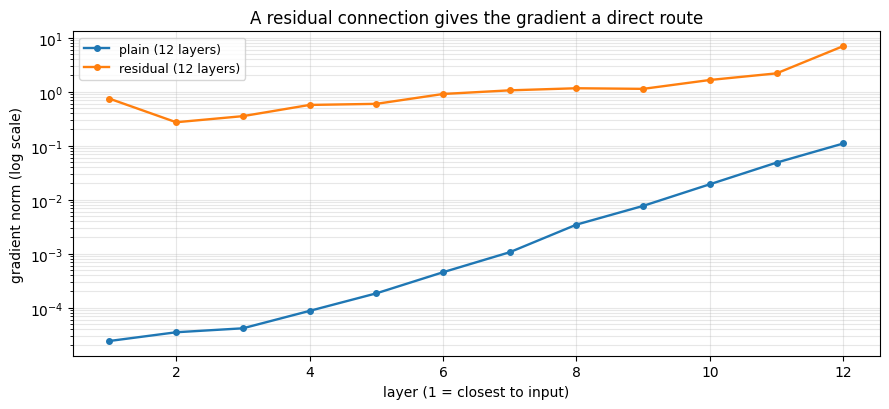

In [13]:
plot_profiles(res_profiles, "A residual connection gives the gradient a direct route")


The experiment shows nearly three orders of magnitude of improvement — roughly a factor of 500 — simply by changing the block from `f(x)` to `x + f(x)`.

The important mechanism is the direct path. In a plain deep network, the gradient must pass through every transformation. In a residual network, part of the gradient can travel along the identity path instead.

This is one reason very deep residual networks can be trained reliably. The problem with adding depth is not only that a larger model can overfit; before residual connections became standard, depth itself could make optimisation difficult because early layers stopped receiving a useful gradient.

There is another useful way to understand residual learning. A residual block does not have to learn the entire desired transformation. It only has to learn the **difference from the identity**. If leaving the representation unchanged is already close to the right thing, the block can make `f(x)` close to zero and let the skip path carry the representation through unchanged.

Real residual architectures sometimes change the width of the representation. In that case, `x` and `f(x)` cannot be added directly because their shapes differ. A common solution is a learned projection — often a linear layer — on the shortcut path so that the two tensors have matching shapes.

**Check your understanding.** If the input has width 64 and the transformed path has width 128, why can you not simply write `x + self.f(x)`? What would a projection on the residual path need to accomplish, and would the shortcut still provide a direct gradient route?

<a id="s8"></a>
## 8. A layer-health checklist

The experiments above are different demonstrations of one underlying idea: **a training curve tells you what happened overall; internal diagnostics help explain why.**

When an unfamiliar model is behaving strangely, you do not want to immediately change five hyperparameters and hope one helps. Start by measuring the internal state of the computation.

The following checklist packages the measurements from this notebook into a quick first pass.

In [14]:
def layer_health_report(model, X, Y, name="model"):
    """Run the Note 3.3 diagnostics on any model. Cheap: one forward/backward pass."""
    print(f"=== layer health: {name} ===")
    norms = layer_grad_norms(model, X, Y)
    first, last = norms[0][1], norms[-1][1]
    ratio = last / max(first, 1e-30)

    print(f"  layers with weight matrices : {len(norms)}")
    print(f"  gradient norm, first layer  : {first:.3e}")
    print(f"  gradient norm, last layer   : {last:.3e}")
    print(f"  ratio last/first            : {ratio:.3e}")

    flags = []
    if ratio > 1e3:   flags.append("VANISHING: early layers receive ~no gradient")
    if ratio < 1e-3:  flags.append("INVERTED: late layers receive ~no gradient")

    # total gradient norm needs its own backward pass, since layer_grad_norms cleared them
    model.train(); model.zero_grad()
    loss_fn(model(X), Y).backward()
    total = torch.sqrt(sum(p.grad.pow(2).sum() for p in model.parameters() if p.grad is not None)).item()
    print(f"  total gradient norm         : {total:.3e}")
    if total > 1e3:            flags.append("EXPLODING: consider clip_grad_norm_")
    if total < 1e-6:           flags.append("NO SIGNAL: total gradient is ~zero")
    if not np.isfinite(total): flags.append("NaN/Inf in gradients")

    # dead units in the first activation, if there is one
    model.eval()
    with torch.no_grad():
        try:
            acts = model[1](model[0](X))
            if isinstance(model[1], nn.ReLU):
                dead = (acts.max(dim=0).values == 0).float().mean().item()
                print(f"  dead units, first ReLU      : {dead:.1%}")
                if dead > 0.5: flags.append(f"DEAD RELU: {dead:.0%} of first-layer units never fire")
        except Exception:
            pass
    model.zero_grad()

    print("  " + ("status: no flags raised" if not flags else "FLAGS:"))
    for f in flags: print(f"    - {f}")
    print()
    return flags

layer_health_report(build_with_init("default"), xb, yb, "3-layer ReLU, default init")
layer_health_report(deep_net("sigmoid", 12), xb, yb, "12-layer sigmoid")
layer_health_report(deep_net("relu", 12, norm="bn"), xb, yb, "12-layer ReLU + BatchNorm")

bad = deep_net("relu", 12)
for mod in bad:
    if isinstance(mod, nn.Linear): nn.init.normal_(mod.weight, 0.0, 1.5)
layer_health_report(bad, xb, yb, "12-layer ReLU, 1.5-sigma init")


=== layer health: 3-layer ReLU, default init ===
  layers with weight matrices : 3
  gradient norm, first layer  : 1.126e-01
  gradient norm, last layer   : 1.434e-01
  ratio last/first            : 1.274e+00
  total gradient norm         : 3.787e-01
  dead units, first ReLU      : 1.6%
  status: no flags raised

=== layer health: 12-layer sigmoid ===
  layers with weight matrices : 12
  gradient norm, first layer  : 1.859e-10
  gradient norm, last layer   : 1.111e+00
  ratio last/first            : 5.977e+09
  total gradient norm         : 1.157e+00
  FLAGS:
    - VANISHING: early layers receive ~no gradient

=== layer health: 12-layer ReLU + BatchNorm ===
  layers with weight matrices : 12
  gradient norm, first layer  : 1.154e+00
  gradient norm, last layer   : 8.440e-01
  ratio last/first            : 7.316e-01
  total gradient norm         : 2.219e+00
  dead units, first ReLU      : 0.0%
  status: no flags raised

=== layer health: 12-layer ReLU, 1.5-sigma init ===
  layers with w

['EXPLODING: consider clip_grad_norm_']

### The checklist, in the order you should run it

1. **Check the total gradient norm.** The absolute value depends on the model and loss, so treat the ranges here as rough warning signs, not laws. A norm above about `1e3` can indicate explosion; a value below about `1e-6` can indicate that the learning signal is effectively disappearing.
2. **Check the per-layer gradient profile.** Look for a large systematic gap between early and late layers. A last/first ratio of more than roughly three orders of magnitude is a strong reason to investigate.
3. **Check the fraction of dead ReLU units.** A small inactive fraction can be normal. If roughly half or more of a layer is permanently inactive, most of that layer's capacity has been lost.
4. **Check explicitly for `NaN` and `Inf`.** These values can propagate through subsequent calculations and turn a useful numerical computation into nonsense.
5. **Check activation scale.** If pre-activation standard deviations are extremely large or extremely small, investigate initialisation, input scaling, learning rate, or normalisation.

These checks are diagnostic signals, not universal pass/fail thresholds. The exact healthy range depends on architecture, parameterisation, batch size, loss, and data. Their value is that they turn a vague statement such as **"the model is not learning"** into a more specific question such as **"the early layers are receiving gradients 10,000 times smaller than the final layer."**

### What to take away

**A summed gradient norm hides structure.** Per-layer measurements tell you where the learning signal is being lost or amplified.

**Initialisation affects the starting numerical regime.** All-zero weights preserve symmetry and prevent hidden units from specialising; excessively large weights can create extreme activations and gradients. Standard PyTorch layers already use sensible defaults, so the skill is recognising broken behaviour rather than memorising a custom initialisation recipe.

**Vanishing and exploding gradients have the same mathematical family.** Both arise from repeated multiplication through the chain rule. When the factors are effectively below one, gradients shrink; when they are effectively above one, they grow.

**Dead ReLU units are a local, potentially permanent failure.** A unit that receives zero gradient because it is always in ReLU's inactive region cannot repair itself during that run. Excessive learning rates are one important cause.

**Normalisation and residual connections address gradient flow structurally.** Normalisation controls activation scale; residual connections provide a shortcut path for information and gradients. These are not arbitrary tricks — each changes a specific part of the computation that was causing the problem.

### Transition to Note 3.4

You now have three kinds of diagnostic evidence:

- **Note 3.1:** learning-rate and optimisation signatures
- **Note 3.2:** generalisation and overfitting signatures
- **Note 3.3:** gradient-flow and internal-layer signatures

The remaining problem is procedural. When a new experiment fails, **which measurement should you make first?** And how do you avoid changing settings until something happens and then mistaking the change for a diagnosis?

Note 3.4 turns these measurements into a diagnostic protocol ordered by cost and evidence, then gives you six deliberately broken experiments to diagnose — including a case where the usual curves look healthy even though the model is still not useful.
